In [15]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [16]:
# Mount Google Drive and load dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DailyDelhiClimateTrain.csv')
print('Shape:', df.shape)
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (1462, 5)
         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000


In [17]:
# Use all 4 features: meantemp, humidity, wind_speed, meanpressure
# We predict meantemp (first column)
features = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
data_raw = df[features].values

# Normalize all features
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_raw)

# Separate scaler for target (meantemp) to inverse transform later
scaler_temp = MinMaxScaler()
scaler_temp.fit(df[['meantemp']].values)

print('Data normalized! Shape:', data_scaled.shape)

Data normalized! Shape: (1462, 4)


In [18]:
# Create sliding window: last 7 days (all 4 features) -> next day temperature
def create_sequences(data, window=7):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])        # shape: (7, 4)
        y.append(data[i+window, 0])       # only meantemp (index 0)
    return np.array(X), np.array(y).reshape(-1, 1)

X, y = create_sequences(data_scaled, window=7)
print('X shape:', X.shape)   # (samples, 7, 4)
print('y shape:', y.shape)   # (samples, 1)

X shape: (1455, 7, 4)
y shape: (1455, 1)


In [19]:
# Split into train / validation / test
n = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]

print('Train:', len(X_train), '| Val:', len(X_val), '| Test:', len(X_test))

Train: 1018 | Val: 218 | Test: 219


In [20]:
# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

# DataLoader for mini-batch training
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

print('Tensors and DataLoader ready!')

Tensors and DataLoader ready!


In [21]:
# Define Simple RNN model (baseline)
class SimpleRNN(nn.Module):
    def __init__(self):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size=4, hidden_size=32, batch_first=True)
        self.fc  = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # take last timestep output
        return out

# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=4, hidden_size=32, batch_first=True)
        self.fc   = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# Define GRU model
class GRUModel(nn.Module):
    def __init__(self):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size=4, hidden_size=32, batch_first=True)
        self.fc  = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

In [22]:
# Function to train any model using DataLoader
def train_model(model, epochs=50):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    train_losses = []
    val_losses   = []

    for epoch in range(epochs):
        # Training step with mini-batches
        model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        loss_train = np.mean(batch_losses)

        # Validation step
        model.eval()
        with torch.no_grad():
            pred_val = model(X_val_t)
            loss_val = criterion(pred_val, y_val_t).item()

        train_losses.append(loss_train)
        val_losses.append(loss_val)

        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs} | Train: {loss_train:.4f} | Val: {loss_val:.4f}')

    return train_losses, val_losses

In [23]:
# Function to evaluate any model
def evaluate_model(model, name):
    model.eval()
    with torch.no_grad():
        pred_test = model(X_test_t).numpy()

    # Inverse transform only the temperature column
    pred_original = scaler_temp.inverse_transform(pred_test)
    y_original    = scaler_temp.inverse_transform(y_test)

    mae  = mean_absolute_error(y_original, pred_original)
    rmse = np.sqrt(mean_squared_error(y_original, pred_original))

    print(f'{name} | MAE: {mae:.2f} | RMSE: {rmse:.2f}')
    return mae, rmse, pred_original

In [10]:
# Train all models
print('=== Simple RNN ===')
rnn_model = SimpleRNN()
rnn_train_losses, rnn_val_losses = train_model(rnn_model)

print('\n=== LSTM ===')
lstm_model = LSTMModel()
lstm_train_losses, lstm_val_losses = train_model(lstm_model)

print('\n=== GRU ===')
gru_model = GRUModel()
gru_train_losses, gru_val_losses = train_model(gru_model)

=== Simple RNN ===
Epoch 10/50 | Train: 0.0044 | Val: 0.0043
Epoch 20/50 | Train: 0.0034 | Val: 0.0034
Epoch 30/50 | Train: 0.0031 | Val: 0.0032
Epoch 40/50 | Train: 0.0029 | Val: 0.0028
Epoch 50/50 | Train: 0.0028 | Val: 0.0028

=== LSTM ===
Epoch 10/50 | Train: 0.0042 | Val: 0.0039
Epoch 20/50 | Train: 0.0037 | Val: 0.0036
Epoch 30/50 | Train: 0.0033 | Val: 0.0033
Epoch 40/50 | Train: 0.0032 | Val: 0.0030
Epoch 50/50 | Train: 0.0029 | Val: 0.0028

=== GRU ===
Epoch 10/50 | Train: 0.0035 | Val: 0.0031
Epoch 20/50 | Train: 0.0031 | Val: 0.0029
Epoch 30/50 | Train: 0.0029 | Val: 0.0027
Epoch 40/50 | Train: 0.0028 | Val: 0.0026
Epoch 50/50 | Train: 0.0027 | Val: 0.0025


In [11]:
# Evaluate all models
print('=== Results ===')
rnn_mae,  rnn_rmse,  rnn_pred  = evaluate_model(rnn_model,  'Simple RNN')
lstm_mae, lstm_rmse, lstm_pred = evaluate_model(lstm_model, 'LSTM')
gru_mae,  gru_rmse,  gru_pred  = evaluate_model(gru_model,  'GRU')

# Comparison table
print('\n=== Comparison Table ===')
print(f'{"Model":<12} {"MAE":>8} {"RMSE":>8}')
print('-' * 30)
print(f'{"Simple RNN":<12} {rnn_mae:>8.2f} {rnn_rmse:>8.2f}')
print(f'{"LSTM":<12} {lstm_mae:>8.2f} {lstm_rmse:>8.2f}')
print(f'{"GRU":<12} {gru_mae:>8.2f} {gru_rmse:>8.2f}')

=== Results ===
Simple RNN | MAE: 1.30 | RMSE: 1.68
LSTM | MAE: 1.42 | RMSE: 1.84
GRU | MAE: 1.31 | RMSE: 1.74

=== Comparison Table ===
Model             MAE     RMSE
------------------------------
Simple RNN       1.30     1.68
LSTM             1.42     1.84
GRU              1.31     1.74


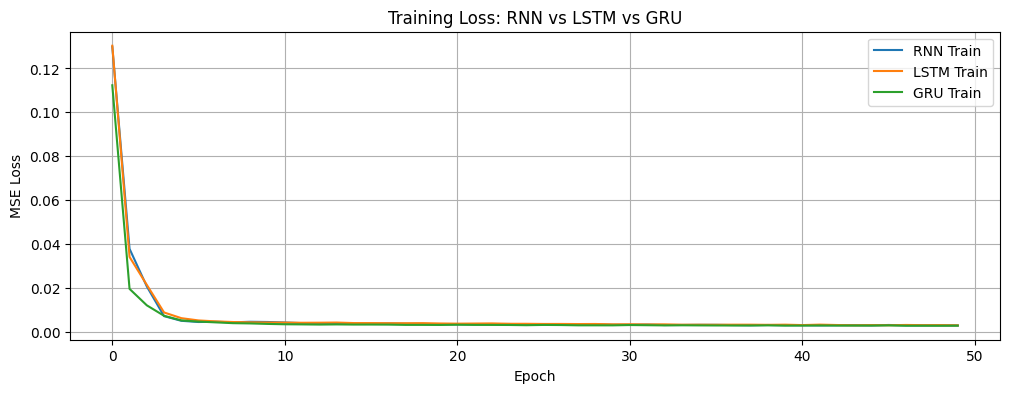

In [12]:
# Plot loss curves
plt.figure(figsize=(12, 4))
plt.plot(rnn_train_losses,  label='RNN Train')
plt.plot(lstm_train_losses, label='LSTM Train')
plt.plot(gru_train_losses,  label='GRU Train')
plt.title('Training Loss: RNN vs LSTM vs GRU')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_comparison.png')
plt.show()

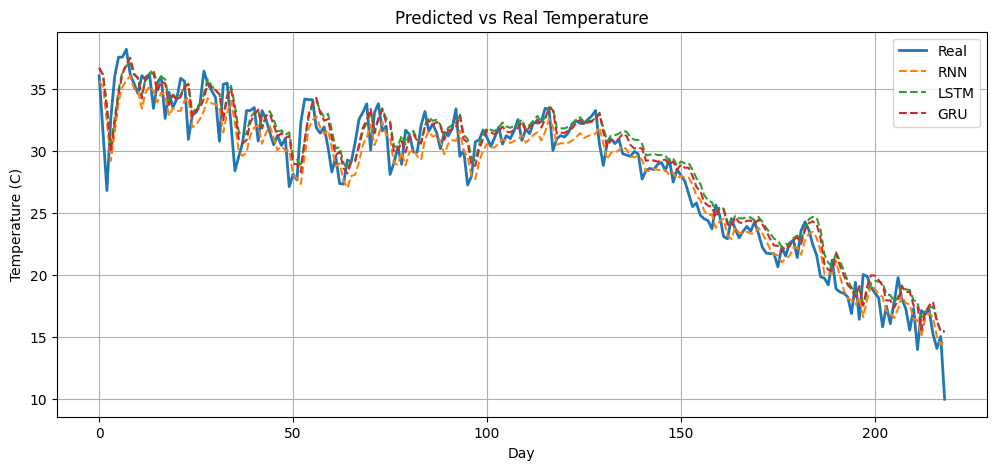

In [13]:
# Plot predictions vs real
y_original = scaler_temp.inverse_transform(y_test)

plt.figure(figsize=(12, 5))
plt.plot(y_original,  label='Real',      linewidth=2)
plt.plot(rnn_pred,    label='RNN',        linestyle='--')
plt.plot(lstm_pred,   label='LSTM',       linestyle='--')
plt.plot(gru_pred,    label='GRU',        linestyle='--')
plt.title('Predicted vs Real Temperature')
plt.xlabel('Day')
plt.ylabel('Temperature (C)')
plt.legend()
plt.grid(True)
plt.savefig('predictions_comparison.png')
plt.show()

 Error Analysis (LSTM) 
Mean error:  1.42 C
Max error:   6.80 C
Days where error > 5C: 3 out of 219


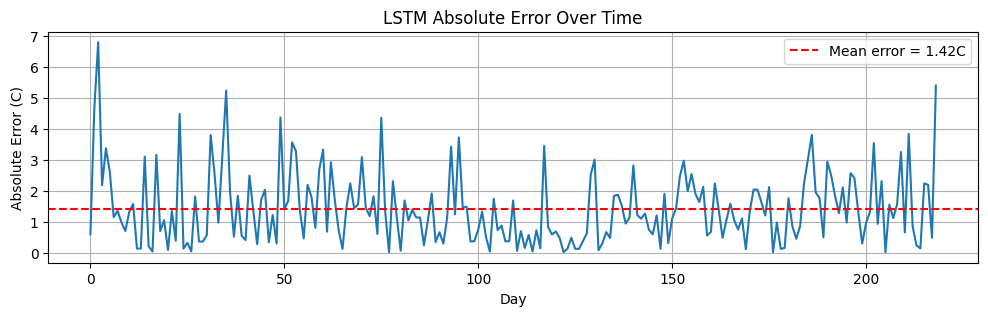


The model tends to make larger errors during seasonal transitions,
when temperature changes rapidly from one day to the next.
LSTM and GRU handle this better than Simple RNN due to their gating mechanisms.


In [24]:
# Error analysis
# Look at where the best model (LSTM) makes the biggest mistakes
errors = np.abs(y_original - lstm_pred).flatten()

print(' Error Analysis (LSTM) ')
print(f'Mean error:  {errors.mean():.2f} C')
print(f'Max error:   {errors.max():.2f} C')
print(f'Days where error > 5C: {(errors > 5).sum()} out of {len(errors)}')

# Plot error over time
plt.figure(figsize=(12, 3))
plt.plot(errors)
plt.axhline(y=errors.mean(), color='r', linestyle='--', label=f'Mean error = {errors.mean():.2f}C')
plt.title('LSTM Absolute Error Over Time')
plt.xlabel('Day')
plt.ylabel('Absolute Error (C)')
plt.legend()
plt.grid(True)
plt.savefig('error_analysis.png')
plt.show()

print('\nThe model tends to make larger errors during seasonal transitions,')
print('when temperature changes rapidly from one day to the next.')
print('LSTM and GRU handle this better than Simple RNN due to their gating mechanisms.')